In [9]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import pandas as pd
import warnings
from IPython.display import display
import matplotlib.pyplot as plt

# **Check DWH connection**

In [10]:
load_dotenv(find_dotenv())
env_data_dir = os.getenv("DATA_DIR")
project_root = os.getenv('PROJECT_ROOT') 

if project_root not in sys.path:
    sys.path.append(project_root)

PROJECT_ROOT = os.getenv("PROJECT_ROOT")
IPAI_PROJECT_DIR = os.getenv("IPAI_PROJECT_DIR") 
BASE_DATA_DIR = Path(env_data_dir) if env_data_dir else project_root / "data"
CLEANED_CSV_DIR = BASE_DATA_DIR / "csv_cleaned"

if not IPAI_PROJECT_DIR:
    raise ValueError("IPAI_PROJECT_DIR is not set in the .env file!")

if IPAI_PROJECT_DIR not in sys.path:
    sys.path.append(IPAI_PROJECT_DIR)

from src.database.connection_manager import db_manager

print("Testing connection to AWS RDS...")

try:
    with db_manager.get_dwh_connection() as conn:
        with conn.cursor() as cursor:
            
            cursor.execute("SELECT VERSION();")
            version = cursor.fetchone()
            
            print(f"Success! Connected to AWS RDS.")
            print(f"Database version: {version[0]}")
            
            cursor.execute("SHOW DATABASES;")
            databases = [db[0] for db in cursor.fetchall()]
            print(f"Available databases: {databases}")
            
except Exception as e:
    print(f"Test error: {e}")

Testing connection to AWS RDS...
Success! Connected to AWS RDS.
Database version: 8.4.8
Available databases: ['eliqsir_dwh', 'information_schema', 'mysql', 'performance_schema', 'sys']


# **DWH schema creation**

### Data Warehouse Architecture: Temporal Star Schema

ELIQSIR Data Warehouse is hosted on AWS RDS (MySQL). The database is structured using a **Temporal Star Schema**, optimized for fast analytical queries.

The schema consists of a central Fact table surrounded by descriptive Dimension tables, enforcing a strict 1-to-Many relational model to maintain data integrity.

#### 1. The Fact Table (`fact_bioactivity`)
Fact Table **granularity** is defined as one single bioactivity measurement (e.g., an IC50 or Ki value) from a specific assay.
* **Metrics:** Contains quantitative values (`standard_value`, `pchembl_value`), measurement types, units, and confidence scores.
* **Temporal Precision:** Includes a `date_precision` flag (Exact, Month, Year, Unknown) to indicate the exactness of the publication date, allowing handle temporal uncertainty.

#### 2. The Contextual Dimensions
* **`dim_protein` (Biological Targets):** Stores human proteome data mapped from UniProt. Key features: `sequence`, `sequence_length`, and `protein_families`.
* **`dim_drug` (Chemical Compounds):** Stores small molecule metadata from ChEMBL. Key features: structural representations (`canonical_smiles`, `standard_inchi_key`) and physiochemical properties.
* **`dim_structure` (3D Conformations):** Maps proteins to physical 3D structures from PDBe, storing metadata like `pdb_id`, `resolution`, and `coverage`.
* **`dim_article` (Literature Context):** Contains metadata about the scientific papers where the bioactivity was reported. Stores `article_title`, `journal`, `abstracts`, and `authors`.

#### 3. The Temporal Dimension: Data-Driven & Role-Playing (`dim_date`)
Dimention `dim_date` is implemented as a **Data-Driven Dimension**. It is dynamically populated exclusively with unique dates that exist within the fact table records.
* **Role-Playing Architecture:** A single `dim_date` table serves six concurrent "roles" for every fact record, representing the complete research lifecycle: `publication`, `received`, `revised`, `accepted`, `epub`, and `ppub`.
* **Referential Integrity:** By extracting the temporal basis directly from the fact data (via `SELECT DISTINCT ... UNION`), the pipeline ensures 100% referential integrity with zero storage overhead for unused dates. Missing or invalid dates are strictly defaulted to `19000101` (Unknown Anchor). Attributes like `fractional_year` and `day_of_week` are pre-calculated.

#### 4. Entity-Relationship Mapping (Keys & Constraints)
The Star Schema enforces strict relational integrity through Surrogate Primary Keys (PK) and corresponding Foreign Keys (FK).

**Dimension Tables (The "1" Side):**
Each dimension uses a surrogate integer Primary Key to decouple the warehouse from source-system changes.
* `dim_protein`: **PK** `protein_key` (Natural Key: `uniprot_id`)
* `dim_drug`: **PK** `drug_key` (Natural Key: `chembl_id`)
* `dim_article`: **PK** `article_key` (Natural Key: `pubmed_id`)
* `dim_structure`: **PK** `structure_key` (Natural Key: `pdb_id`)
* `dim_date`: **PK** `date_key` (Format: `YYYYMMDD` integer)
  * NOTE: this surrogate key is generated from the actual date values in the fact table, ensuring referential integrity, as opposed to auto-incrementing managed by the DMS.

**Fact Table (The "Many" Side):**
The `fact_bioactivity` table acts as the bridge connecting all dimensions.
* **PK:** `fact_id` (Auto-incrementing)
* **FK (Biology/Chemistry/Literature):** `protein_key`, `drug_key`, `structure_key`, `article_key`.
* **FK (Temporal Roles):**
    * `publication_date_key` -> references `dim_date(date_key)`
    * `received_date_key` -> references `dim_date(date_key)`
    * `revised_date_key` -> references `dim_date(date_key)`
    * `accepted_date_key` -> references `dim_date(date_key)`
    * `epub_date_key` -> references `dim_date(date_key)`
    * `ppub_date_key` -> references `dim_date(date_key)`

In [ ]:
# 1. Load environment and set up paths
load_dotenv(find_dotenv())

# Fetch the sub-project directory where 'src' is located
IPAI_PROJECT_DIR = os.getenv("IPAI_PROJECT_DIR")

if not IPAI_PROJECT_DIR:
    raise ValueError("IPAI_PROJECT_DIR is not set in the .env file!")

# Add the sub-project directory to sys.path for imports
if IPAI_PROJECT_DIR not in sys.path:
    sys.path.append(IPAI_PROJECT_DIR)

from src.database.connection_manager import db_manager

# 2. Define the path to the schema.sql file using the new project directory
schema_file_path = os.path.join(IPAI_PROJECT_DIR, "src", "database", "schema.sql")

print(f"Looking for schema file at: {schema_file_path}")

try:
    # 3. Read the SQL file content
    with open(schema_file_path, 'r', encoding='utf-8') as file:
        sql_script = file.read()
    
    print("File loaded. Executing SQL statements on AWS RDS...")
    
    # 4. Split the script into individual statements
    # This bypasses the connector's 'multi' limitation
    sql_statements = sql_script.split(';')
    
    with db_manager.get_dwh_connection() as conn:
        # Use context manager for the cursor to ensure it closes properly
        with conn.cursor() as cursor:
            
            for statement in sql_statements:
                clean_statement = statement.strip()
                # Only execute if the statement isn't just empty space or newlines
                if clean_statement:
                    cursor.execute(clean_statement)
            
            # Commit the changes to the database
            conn.commit()
            
            print("Schema executed successfully!")
            
            # 5. Verification: Check if the tables were actually created
            cursor.execute("SHOW TABLES;")
            tables = [table[0] for table in cursor.fetchall()]
            
            print(f"\nTables currently in the 'eliqsir_dwh' database:")
            for table in tables:
                print(f" - {table}")
            
except FileNotFoundError:
    print(f"Error: Could not find the file 'schema.sql'. Check the path.")
except Exception as e:
    print(f"Execution error: {e}")

Looking for schema file at: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\ipai_project\src\database\schema.sql
File loaded. Executing SQL statements on AWS RDS...
Schema executed successfully!

Tables currently in the 'eliqsir_dwh' database:
 - dim_article
 - dim_drug
 - dim_protein
 - dim_structure
 - fact_bioactivity


# **ETL**

## **Extraction**

**To run the extraction correctly you need to perform following steps to have chembl db locally:**
1. Go to the official European Bioinformatics Institute FTP site: ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/

2. Download the file named chembl_36_sqlite.tar.gz 
3. Unzip/extract that file locally to data/ChEMBL project folder

### Extraction Layer: API Integration & Raw Data Acquisition

The **Extraction (E)** phase of the ELIQSIR ETL pipeline. This layer is responsible for querying external biological, chemical, and literature databases to retrieve the foundational datasets, saving the unformatted results directly into raw CSV files.

The extraction process relies on four dedicated API/Database clients:

* **UniProt Extraction (`UniProtExtractor`):** Connects to the UniProt REST API to stream reviewed (Swiss-Prot) human proteome entries, capturing critical ML features like protein sequences, lengths, and family classifications.
* **ChEMBL Bioactivity Extraction (`ChemblExtractor`):** Queries a local ChEMBL SQLite database to extract high-quality bioactivity records (e.g., IC50, Ki), drug metadata (SMILES, molecular weight, molecule type), and literature mappings for specific protein targets. Uses internal batching and Parquet caching for high-performance querying.
* **PDBe Structure Extraction (`PdbeExtractor`):** Fetches curated, high-resolution 3D protein structures mapping to our collected UniProt accessions via the PDBe Graph API.
* **PubMed Abstract Extraction (`PubMedExtractor`):** Uses the NCBI Entrez E-utilities API to fetch article metadata (including precise publication dates for temporal modeling), full abstracts, and complete author lists based on PMIDs. Operates in configured batches with enforced delays to comply with NCBI rate-limiting policies.

**Output:** A set of raw, unaltered CSV files (`chembl_raw.csv`, `pdbe_raw.csv`, `pubmed_raw.csv`, `uniprot_raw.csv`) stored in the local `data/csv/` directory, serving as the immutable starting point for the Transformation layer.

In [ ]:
# 1. Load environment variables
load_dotenv(find_dotenv())

# Fetch variables from the environment
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
IPAI_PROJECT_DIR = os.getenv("IPAI_PROJECT_DIR")
DATA_DIR = os.getenv("DATA_DIR")
NCBI_EMAIL = os.getenv("NCBI_EMAIL")

# Ensure all critical variables are present
if not all([PROJECT_ROOT, IPAI_PROJECT_DIR, DATA_DIR, NCBI_EMAIL]):
    raise ValueError("Missing critical environment variables in the .env file!")

# Add the sub-project directory to sys.path so Python can find the 'src' module
if IPAI_PROJECT_DIR not in sys.path:
    sys.path.append(IPAI_PROJECT_DIR)

# 2. Set up the output directory
csv_dir = Path(DATA_DIR) / "csv"
csv_dir.mkdir(parents=True, exist_ok=True)

# Import the extractors from the src package
from src.etl.extraction import UniProtExtractor, ChemblExtractor, PdbeExtractor, PubMedExtractor

print(f"Starting ELIQSIR Extraction Pipeline...")
print(f"Output directory: {csv_dir}")

# -------------------------------------------------------------------
# STAGE 1: UniProt (The Foundation)
# -------------------------------------------------------------------
print("\n--- STAGE 1: Extracting UniProt Data ---")
uniprot_ext = UniProtExtractor()
df_uniprot = uniprot_ext.extract()

# Save raw CSV
df_uniprot.to_csv(csv_dir / "uniprot_raw.csv", index=False)

# Get the list of UniProt IDs for the next steps
uniprot_ids = df_uniprot['uniprot_id'].dropna().unique().tolist()

# TEST MODE: Keep only the first 50 proteins for a fast test run. 
# Remove or comment out the next line when you are ready to extract everything!
# uniprot_ids = uniprot_ids[:50] 
print(f"Proceeding with {len(uniprot_ids)} proteins for downstream extraction...")

# -------------------------------------------------------------------
# STAGE 2: ChEMBL (The Bioactivity & Drugs)
# -------------------------------------------------------------------
print("\n--- STAGE 2: Extracting ChEMBL Data ---")
# The ChEMBL extractor expects to find the 'chembl_36' folder inside this directory
chembl_base_dir = Path(DATA_DIR) / "ChEMBL" 

try:
    chembl_ext = ChemblExtractor(chembl_dir=chembl_base_dir)
    df_chembl = chembl_ext.extract(uniprot_ids=uniprot_ids)
    df_chembl.to_csv(csv_dir / "chembl_raw.csv", index=False)
    
    # Get PubMed IDs for Stage 3
    pubmed_ids = df_chembl['pubmed_id'].dropna().unique().tolist()
except FileNotFoundError as e:
    print(f"\nChEMBL Extraction Skipped: {e}")
    print("Please ensure your ChEMBL SQLite database is downloaded and extracted.")
    pubmed_ids = [] # Fallback if ChEMBL isn't downloaded yet

# -------------------------------------------------------------------
# STAGE 3: PubMed (The Articles)
# -------------------------------------------------------------------
print("\n--- STAGE 3: Extracting PubMed Data ---")
if pubmed_ids:
    pubmed_ext = PubMedExtractor(email=NCBI_EMAIL)
    df_pubmed = pubmed_ext.extract(pubmed_ids=pubmed_ids)
    df_pubmed.to_csv(csv_dir / "pubmed_raw.csv", index=False)
else:
    print("No PubMed IDs found (ChEMBL likely skipped). Skipping PubMed.")

# -------------------------------------------------------------------
# STAGE 4: PDBe (The 3D Structures)
# -------------------------------------------------------------------
print("\n--- STAGE 4: Extracting PDBe Data ---")
pdbe_ext = PdbeExtractor()
df_pdbe = pdbe_ext.extract(uniprot_ids=uniprot_ids)
df_pdbe.to_csv(csv_dir / "pdbe_raw.csv", index=False)

print(f"\nPipeline complete! All files saved to: {csv_dir}")

Starting ELIQSIR Extraction Pipeline...
Output directory: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv

--- STAGE 1: Extracting UniProt Data ---
2026-03-29 21:47:55  INFO      src.extraction.uniprot_extractor  Fetching UniProt data – organism_id=9606, reviewed=True
2026-03-29 21:48:07  INFO      src.extraction.uniprot_extractor  UniProt extraction complete – 20431 proteins retrieved.
Proceeding with 20431 proteins for downstream extraction...

--- STAGE 2: Extracting ChEMBL Data ---
2026-03-29 21:48:08  INFO      src.extraction.chembl_extractor  ============================================================
2026-03-29 21:48:08  INFO      src.extraction.chembl_extractor  ChEMBL SQLite Extractor initialized
2026-03-29 21:48:08  INFO      src.extraction.chembl_extractor    Version  : 36
2026-03-29 21:48:08  INFO      src.extraction.chembl_extractor    Database : data\ChEMBL\chembl_36\chembl_36_sqlite\chembl_36.db
2026-03-29 21:48:08  INFO      src.extraction.chembl_extractor   

## **Transformation**

### Transformation Layer: Data Cleaning & Dimensional Modeling

**Transformation (T)** phase of the ELIQSIR ETL pipeline. This layer acts as the bridge between raw extracted datasets (CSV files) and our target Star Schema Data Warehouse, ensuring data quality, consistency, and relational integrity.

The transformation process is divided into two sequential stages:

#### 1. Data Cleaning (`DataCleaner`)
Raw pandas DataFrames from the Extraction layer are cleaned using non-destructive operations:
* **Type Casting:** Converting strings to appropriate numeric types (e.g., floats for `molecular_weight` and `standard_value`, nullable `Int64` for `pubmed_id` and `year`).
* **Missing Value & Artifact Handling:** Dropping rows missing critical identifiers (e.g., target or drug IDs), handling string artifacts (like `"None"` in publication dates), and safely preserving non-critical missing data as `pd.NA` (which translates to SQL `NULL`).
* **Normalization & Deduplication:** Stripping whitespace, removing exact duplicates, and canonicalizing identifiers (e.g., uppercase UniProt and PDB IDs).

#### 2. Dimensional Building (`DimensionalModelBuilder`)
Cleaned DataFrames are restructured into a **Temporal Star Schema** consisting of Dimension and Fact tables:
* **Temporal Foundation Generation:** Extracting and formatting raw dates into standardized `YYYYMMDD` integer keys. This establishes the exact chronological basis needed to dynamically generate our **Data-Driven** `dim_date` table inside the data warehouse.
* **Surrogate Key Generation:** Mapping natural string keys (e.g., `uniprot_id`, `drug_chembl_id`) to optimized integer surrogate keys (`protein_key`, `drug_key`) for faster SQL indexing.
* **Entity Integration:** Merging distinct data sources (e.g., joining PubMed abstracts with ChEMBL article metadata to extract high-precision publication dates).
* **Fact Table Assembly:** Resolving foreign keys to securely link the central `fact_bioactivity` table to the surrounding dimensions (`dim_protein`, `dim_drug`, `dim_article`, `dim_structure`). This includes assigning the core `publication_date_key`, properly setting `date_precision` values, and initializing the temporal placeholders (e.g., `received_date_key = 19000101`) to prepare the records for the subsequent API Enrichment phase.

**Output:** A set of normalized, relational DataFrames that will be saved into cleaned CSV files ready for database insertion.

In [ ]:
# Import transformation classes
from src.etl.transformation.cleaner import DataCleaner
from src.etl.transformation.dimensional_builder import DimensionalModelBuilder
import pandas as pd
import os
from pathlib import Path
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
BASE_DATA_DIR = Path(os.getenv("DATA_DIR", "data"))
INPUT_DIR = BASE_DATA_DIR / "csv"
OUTPUT_DIR = BASE_DATA_DIR / "csv_cleaned"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Initialize a dictionary to track row counts for the final report
report = {}

# 1. Load Raw Data
print(f"Loading raw CSV files from: {INPUT_DIR}")
raw_uniprot = pd.read_csv(INPUT_DIR / "uniprot_raw.csv")
raw_chembl = pd.read_csv(INPUT_DIR / "chembl_raw.csv", low_memory=False)
raw_pdbe = pd.read_csv(INPUT_DIR / "pdbe_raw.csv")
raw_pubmed = pd.read_csv(INPUT_DIR / "pubmed_raw.csv")

report["raw"] = {
    "UniProt": len(raw_uniprot),
    "ChEMBL": len(raw_chembl),
    "PDBe": len(raw_pdbe),
    "PubMed": len(raw_pubmed)
}

# 2. Clean Data
print("Cleaning data...")
cleaner = DataCleaner()
clean_uniprot = cleaner.clean_uniprot(raw_uniprot)
clean_chembl = cleaner.clean_chembl(raw_chembl)
clean_pdbe = cleaner.clean_pdbe(raw_pdbe)
clean_pubmed = cleaner.clean_pubmed(raw_pubmed) 

report["clean"] = {
    "UniProt": len(clean_uniprot),
    "ChEMBL": len(clean_chembl),
    "PDBe": len(clean_pdbe),
    "PubMed": len(clean_pubmed)
}

# 3. Build Dimensional Model
print("Building Star Schema dimensions and facts...")
builder = DimensionalModelBuilder()

dim_protein = builder.build_dim_protein(clean_uniprot)
dim_drug = builder.build_dim_drug(clean_chembl)
dim_article = builder.build_dim_article(clean_chembl, clean_pubmed)
dim_structure = builder.build_dim_structure(clean_pdbe)

fact_bioactivity = builder.build_fact_bioactivity(clean_chembl, clean_pubmed)

dim_date = builder.build_dim_date(fact_bioactivity)

report["dim"] = {
    "dim_date": len(dim_date),
    "dim_protein": len(dim_protein),
    "dim_drug": len(dim_drug),
    "dim_article": len(dim_article),
    "dim_structure": len(dim_structure),
    "fact_bioactivity": len(fact_bioactivity)
}

# 4. Save to target directory
print(f"Saving cleaned dimensional files to: {OUTPUT_DIR}")
dim_date.to_csv(OUTPUT_DIR / "dim_date.csv", index=False)
dim_protein.to_csv(OUTPUT_DIR / "dim_protein.csv", index=False)
dim_drug.to_csv(OUTPUT_DIR / "dim_drug.csv", index=False)
dim_article.to_csv(OUTPUT_DIR / "dim_article.csv", index=False)
dim_structure.to_csv(OUTPUT_DIR / "dim_structure.csv", index=False)
fact_bioactivity.to_csv(OUTPUT_DIR / "fact_bioactivity.csv", index=False)

# 5. Generate and print the metrics report
print("\n" + "="*60)
print("ELIQSIR TRANSFORMATION PIPELINE REPORT")
print("="*60)

print("\n--- 1. Data Cleaning (Raw -> Clean) ---")
for dataset in ["UniProt", "ChEMBL", "PDBe", "PubMed"]:
    raw_count = report['raw'][dataset]
    clean_count = report['clean'][dataset]
    dropped = raw_count - clean_count
    retention = (clean_count / raw_count * 100) if raw_count > 0 else 0
    print(f"{dataset:<10} | Raw: {raw_count:<8} | Clean: {clean_count:<8} | Dropped: {dropped:<6} | Retention: {retention:.1f}%")

print("\n--- 2. Dimensional Model (Final Tables) ---")
for table, count in report['dim'].items():
    print(f"{table:<20} | Rows: {count}")

print("="*60)
print("Pipeline execution completed successfully. Data saved.")

Loading raw CSV files from: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv
Cleaning data...
2026-04-02 21:57:44  INFO      src.etl.transformation.cleaner  UniProt cleaning complete - 20431 proteins retained.
2026-04-02 21:59:24  INFO      src.etl.transformation.cleaner  ChEMBL cleaning complete - 6441095 bioactivity records retained.
2026-04-02 21:59:49  INFO      src.etl.transformation.cleaner  PDBe cleaning complete - 225204 structure entries retained.
2026-04-02 21:59:53  INFO      src.etl.transformation.cleaner  PubMed cleaning complete - 36351 abstracts retained.
Building Star Schema dimensions and facts...
2026-04-02 21:59:53  INFO      src.etl.transformation.dimensional_builder  Building DimDate from 1950 to 2030.
2026-04-02 21:59:54  INFO      src.etl.transformation.dimensional_builder  Building DimProtein - 20431 input rows.
2026-04-02 21:59:54  INFO      src.etl.transformation.dimensional_builder  Building DimDrug.
2026-04-02 22:00:05  INFO      src.etl.transformat

### Transformation Results: Pre-Load Data Inspection & Star Schema Validation

To ensure the integrity of our ETL process, we visually inspect the generated Dimensional and Fact tables. 
Note: string identifiers (like `uniprot_id` or `drug_chembl_id`) have been supplemented or replaced with optimized integer surrogate keys (`protein_key`, `drug_key`, etc.) to prepare the data for efficient relational querying and possible HDF5 graph construction.

In [9]:
load_dotenv()
BASE_DATA_DIR = Path(os.getenv("DATA_DIR", "data"))
CLEANED_CSV_DIR = BASE_DATA_DIR / "csv_cleaned"

# List of tables in our Star Schema (now including dim_date)
tables = [
    "dim_date",         
    "dim_protein",
    "dim_drug",
    "dim_article",
    "dim_structure",
    "fact_bioactivity"
]

print("INSPECTING TRANSFORMED DATA\n")

# Loop through each file and display the first 10 rows
for table in tables:
    file_path = CLEANED_CSV_DIR / f"{table}.csv"
    
    if file_path.exists():
        print(f"--- {table.upper()} ---")
        df_head = pd.read_csv(file_path, nrows=10)
        display(df_head)
    else:
        print(f"Warning: File {file_path.name} not found in {CLEANED_CSV_DIR}.")

INSPECTING TRANSFORMED DATA

--- DIM_DATE ---


,date_key,year,month,day,quarter,fractional_year
0,19000101,1900,1,1,1,1900.0
1,19760101,1976,1,1,1,1976.0
2,19770101,1977,1,1,1,1977.0
3,19780101,1978,1,1,1,1978.0
4,19790101,1979,1,1,1,1979.0
5,19800101,1980,1,1,1,1980.0
6,19810101,1981,1,1,1,1981.0
7,19820101,1982,1,1,1,1982.0
8,19830101,1983,1,1,1,1983.0
9,19840101,1984,1,1,1,1984.0


--- DIM_PROTEIN ---


,protein_key,uniprot_id,gene_names,protein_name,sequence,sequence_length,protein_families
0,1,A0A087X1C5,CYP2D7,Cytochrome P450 2D7 (EC 1.14.14.1),MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,515,Cytochrome P450 family
1,2,A0A096LP01,SMIM26 LINC00493,Small integral membrane protein 26,MYRNEFTAWYRRMSVVYGIGTWSVLGSLLYYSRTMAKSSVDQKDGS...,95,SMIM26 family
2,3,A0A0B4J2F0,PIGBOS1,Protein PIGBOS1 (PIGB opposite strand protein 1),MFRRLTFAQLLFATVLGIAGGVYIFQPVFEQYAKDQKELKEKMQLV...,54,NaN
3,4,A0A0C5B5G6,MT-RNR1,Mitochondrial-derived peptide MOTS-c (Mitochon...,MRWQEMGYIFYPRKLR,16,NaN
4,5,A0A0K2S4Q6,CD300H,Protein CD300H (CD300 antigen-like family memb...,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,201,CD300 family
5,6,A0A0U1RRE5,NBDY LINC01420,Negative regulator of P-body association (P-bo...,MGDQPCASGRSTLPPGNAREAKPPKKRCLLAPRWDYPEGTPNGGST...,68,NaN
6,7,A0A1B0GTW7,CIROP LMLN2,Ciliated left-right organizer metallopeptidase...,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788,Peptidase M8 family
7,8,A0A2R8Y7D0,TINCR LINC00036 NCRNA00036 PLAC2,Ubiquitin domain-containing protein TINCR (Pla...,MEGLRRGLSRWKRYHIKVHLADEALLLPLTVRPRDTLSDLRAQLVG...,87,NaN
8,9,A0A8I5KQE6,RPSA2 RPSA RPSAP58,Small ribosomal subunit protein uS2B (37 kDa l...,MSGALDVLQMKEEDVLKFLAAGTHLGGTNLDFQMEHYIYKRKSDGI...,295,Universal ribosomal protein uS2 family
9,10,A0AV02,SLC12A8 CCC9,Solute carrier family 12 member 8 (Cation-chlo...,MTQMSQVQELFHEAAQQDALAQPQPWWKTQLFMWEPVLFGTWDGVF...,714,SLC12A transporter family


--- DIM_DRUG ---


...

,article_key,pubmed_id,article_title,journal,year,abstract,doi,authors,pub_date
0,1,23360215,Exploring a new frontier in cancer treatment: ...,J Med Chem,2013,The labeling of proteins with small ubiquitin ...,10.1021/jm301420b,"da Silva, Sara R; Paiva, Stacey-Lynn; Lukkaril...",2013-3-28
1,2,28505447,Interrogating the Roles of Post-Translational ...,J Med Chem,2018,Post-translational modifications (PTMs) allot ...,10.1021/acs.jmedchem.6b01817,"Buuh, Zakey Yusuf; Lyu, Zhigang; Wang, Rongshe...",2018-4-26
2,3,29501416,Adenosine analogs bearing phosphate isosteres ...,Bioorg Med Chem,2018,The human O-acetyl-ADP-ribose deacetylase MDO1...,10.1016/j.bmc.2018.02.006,"Zhang, Yuezhou; Jumppanen, Mikael; Maksimainen...",2018-5-01
3,4,35131538,NAE modulators: A potential therapy for gastri...,Eur J Med Chem,2022,Neural precursor cell expressed developmentall...,10.1016/j.ejmech.2022.114156,"Liang, Qi; Liu, Maoyu; Li, Jian; Tong, Rongshe...",2022-3-05
4,5,35597097,"Design, synthesis and evaluation of inhibitors...",Bioorg Med Chem,2022,"A series of amino acid based 7H-pyrrolo[2,3-d]...",10.1016/j.bmc.2022.116788,"Sherrill, Lavinia M; Joya, Elva E; Walker, Ann...",2022-8-01
5,6,34748351,Discovery and Optimization of Pyrazole Amides ...,J Med Chem,2021,Accumulation of very long chain fatty acids (V...,10.1021/acs.jmedchem.1c00944,"Come, Jon H; Senter, Timothy J; Clark, Michael...",2021-12-23
6,7,29928781,NVP-BHG712: Effects of Regioisomers on the Aff...,ChemMedChem,2018,Erythropoietin-producing hepatocellular (EPH) ...,10.1002/cmdc.201800398,"Tröster, Alix; Heinzlmeir, Stephanie; Berger, ...",2018-8-20
7,8,28408219,Developing DYRK inhibitors derived from the me...,Bioorg Med Chem Lett,2017,A structure-activity relationship has been dev...,10.1016/j.bmcl.2017.03.037,"Shaw, Simon J; Goff, Dane A; Lin, Nan; Singh, ...",2017-6-01
8,9,28256837,Determination of Gymnemic Acid I as a Protein ...,J Nat Prod,2017,The plant Gymnema sylvestre has been used wide...,10.1021/acs.jnatprod.6b00793,"Capolupo, Angela; Esposito, Roberta; Zampella,...",2017-4-28
9,10,30929949,Profiling withanolide A for therapeutic target...,Bioorg Med Chem,2019,To identify new potential therapeutic targets ...,10.1016/j.bmc.2019.03.022,"Crane, Erika A; Heydenreuter, Wolfgang; Beck, ...",2019-6-15


--- DIM_STRUCTURE ---


,structure_key,protein_key,pdb_id,chain_id,resolution,coverage,method,unp_start,unp_end
0,1,8,7MRJ,A,2.120,0.989,X-ray diffraction,2,87
1,2,8,7MRJ,B,2.120,0.989,X-ray diffraction,2,87
2,3,11,2DIS,A,NaN,0.162,Solution NMR,150,245
3,4,14,4YO2,A,3.073,0.268,X-ray diffraction,110,341
4,5,15,7PVN,A,2.710,1.000,X-ray diffraction,1,1052
5,6,15,7PVN,B,2.710,1.000,X-ray diffraction,1,1052
6,7,15,9QH5,B,3.090,1.000,Electron Microscopy,1,1052
7,8,15,9QIC,B,3.290,1.000,Electron Microscopy,1,1052
8,9,15,9QIV,B,3.440,1.000,Electron Microscopy,1,1052
9,10,15,9QIM,B,3.570,1.000,Electron Microscopy,1,1052


--- FACT_BIOACTIVITY ---


,activity_id,protein_key,drug_key,article_key,publication_date_key,date_precision,standard_type,standard_value,standard_units,pchembl_value,confidence_score,assay_type,assay_description,assay_organism,received_date_key,revised_date_key,accepted_date_key,epub_date_key,ppub_date_key
0,12645440,15,1,1.0,20130328,Exact,IC50,1800.0,nM,5.75,9,B,Inhibition of UBA6 (unknown origin),Homo sapiens,19000101,19000101,19000101,19000101,19000101
1,12645445,15,2,1.0,20130328,Exact,IC50,920.0,nM,6.04,9,B,Inhibition of UBA6 (unknown origin) in presenc...,Homo sapiens,19000101,19000101,19000101,19000101,19000101
2,18483955,15,3,2.0,20180426,Exact,IC50,1000.0,nM,NaN,9,B,Inhibition of UBA6 (unknown origin) assessed a...,Homo sapiens,19000101,19000101,19000101,19000101,19000101
3,18574594,45,4,3.0,20180501,Exact,Kd,150.0,nM,6.82,9,B,Binding affinity to human MDO2 by ITC,Homo sapiens,19000101,19000101,19000101,19000101,19000101
4,24775879,15,3,4.0,20220305,Exact,IC50,1800.0,nM,5.75,9,B,Inhibition of His-tagged UBA6 (unknown origin)...,Homo sapiens,19000101,19000101,19000101,19000101,19000101
5,24778420,45,5,5.0,20220801,Exact,IC50,300000.0,nM,NaN,9,T,Inhibition of N-terminal His-TEV-V5 tagged hum...,Homo sapiens,19000101,19000101,19000101,19000101,19000101
6,24778421,45,6,5.0,20220801,Exact,IC50,300000.0,nM,NaN,9,T,Inhibition of N-terminal His-TEV-V5 tagged hum...,Homo sapiens,19000101,19000101,19000101,19000101,19000101
7,24778436,45,7,5.0,20220801,Exact,IC50,500000.0,nM,NaN,9,T,Inhibition of human Mdo2,Homo sapiens,19000101,19000101,19000101,19000101,19000101
8,24792144,40,8,6.0,20211223,Exact,IC50,500000.0,nM,NaN,9,B,Inhibition of ELOVL7 (unknown origin) using C1...,Homo sapiens,19000101,19000101,19000101,19000101,19000101
9,24792145,40,9,6.0,20211223,Exact,IC50,100000.0,nM,NaN,9,B,Inhibition of ELOVL7 (unknown origin) using C1...,Homo sapiens,19000101,19000101,19000101,19000101,19000101


## **Load**

### Loading Layer: Data Warehouse Integration

The **Loading (L)** phase of the ELIQSIR ETL pipeline. This layer is responsible for taking the fully prepared dimensional and fact CSV files and inserting them into the target AWS RDS MySQL data warehouse.

The loading process is managed by the `WarehouseLoader` and relies on a custom connection manager:

* **Direct Database Connection:** Utilizes a custom `ConnectionManager` leveraging `mysql.connector` to establish secure, pooled connections directly to the AWS RDS instance, avoiding heavy ORM overhead.
* **Memory-Efficient Chunking:** Reads massive CSV files (e.g., ~6.4 million bioactivity records) in configurable chunks (e.g., 10,000 rows at a time). This strictly bounds RAM usage and prevents database transaction timeouts.
* **Null Value Coercion:** Safely casts pandas missing data types (like `pd.NA` and `np.nan`) to native Python `None` objects. This ensures the database driver correctly inserts true SQL `NULL` values, preserving data integrity.
* **High-Performance Upserts (`ON DUPLICATE KEY UPDATE`):** Dynamically generates parameterized SQL statements executed via `cursor.executemany()`. This allows for fast, idempotent bulk inserts that handle both initial loads and incremental updates without duplicating records.
* **Orchestrated Star Schema Loading:** To maintain referential integrity, the loader follows a strict execution order:
    1. **Dimension Population:** Core entity dimensions (`dim_protein`, `dim_drug`, `dim_article`, `dim_structure`) and the **Data-Driven** `dim_date` are loaded first. This ensures all possible foreign key targets exist in the database.
    2. **Fact Integration:** The central `fact_bioactivity` table is loaded last. Since the `publication_date_key` and other temporal placeholders (19000101) were pre-calculated during transformation, the fact table links to the star schema immediately upon insertion.

**Output:** A fully populated Star Schema residing in AWS RDS. This relational foundation is now ready for the **Temporal Enrichment** phase.

In [7]:
project_root = str(Path(os.getcwd()).parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
load_dotenv(Path(project_root) / ".env")
from src.etl.loading.warehouse_loader import WarehouseLoader

BASE_DATA_DIR = Path(os.getenv("DATA_DIR", Path(project_root) / "data"))
CLEANED_CSV_DIR = BASE_DATA_DIR / "csv_cleaned"

print(f"Connecting to AWS RDS and starting bulk load from: {CLEANED_CSV_DIR}")
print("This might take a while depending on your internet connection and chunk size...\n")

# chunksize=10000 is a safe default for remote databas to avoid packet size limits.
# If it runs too slow can be increased to 25000 or 50000 (in case if you do not see network errors).
loader = WarehouseLoader(chunksize=10000) 

try:
    results = loader.load_all(CLEANED_CSV_DIR)

    # Report generation
    print("\n" + "="*60)
    print("ELIQSIR LOADING PIPELINE REPORT (AWS RDS)")
    print("="*60)
    
    for table, rows in results.items():
        print(f"{table:<20} | Successfully inserted/updated: {rows} rows")
    
    total_rows = sum(results.values())
    print("-" * 60)
    print(f"TOTAL ROWS LOADED:   | {total_rows}")
    print("="*60)
    print("Data Warehouse loading completed successfully!")
    
except Exception as e:
    print(f"\nAn error occurred during loading: {e}")

Connecting to AWS RDS and starting bulk load from: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv_cleaned
This might take a while depending on your internet connection and chunk size...

2026-04-02 22:41:19  INFO      src.etl.loading.warehouse_loader  Beginning bulk warehouse load from directory: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv_cleaned
2026-04-02 22:41:19  INFO      src.etl.loading.warehouse_loader  Starting load for 'dim_protein' from C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv_cleaned\dim_protein.csv
2026-04-02 22:41:25  INFO      src.etl.loading.warehouse_loader  Finished loading 'dim_protein'. Total rows: 20431
2026-04-02 22:41:25  INFO      src.etl.loading.warehouse_loader  Starting load for 'dim_drug' from C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv_cleaned\dim_drug.csv
2026-04-02 22:41:30  INFO      src.etl.loading.warehouse_loader  ... loaded 50000 rows into 'dim_drug'
2026-04-02 22:41:34  INFO      src.etl.loadin

### Loading Results: Live Data Warehouse Verification

To confirm the successful execution of Loading layer, we query the live AWS RDS MySQL database directly. 
By fetching the first few rows from each table in our Star Schema, we verify that the data was not only transferred successfully over the network but also correctly parsed, typed, and indexed by the database engine.

In [10]:
# Suppress pandas warning about using raw DBAPI connections instead of SQLAlchemy
warnings.filterwarnings('ignore', category=UserWarning)
from src.database.connection_manager import db_manager

print("AWS RDS Verification: Querying Live Data\n")

tables = [
    "dim_date",          
    "dim_protein",
    "dim_drug",
    "dim_article",
    "dim_structure",
    "fact_bioactivity"
]

try:
    with db_manager.get_dwh_connection() as conn:
        for table in tables:
            print(f"LIVE TABLE: {table.upper()}")
            
            # Fetch only the first 10 rows directly from the cloud database
            query = f"SELECT * FROM `{table}` LIMIT 10;"
            df_head = pd.read_sql(query, con=conn)
            
            display(df_head)
            
except Exception as e:
    print(f"Database connection or query failed: {e}")

AWS RDS Verification: Querying Live Data

LIVE TABLE: DIM_DATE


,date_key,full_date,year,month,day,quarter,day_of_week,is_weekend,fractional_year,epoch_time
0,19000101,1900-01-01,1900,1,1,1,0,0,1900.000000,0
1,19500101,1950-01-01,1950,1,1,1,6,1,1950.000000,-631152000
2,19500102,1950-01-02,1950,1,2,1,0,0,1950.002740,-631065600
3,19500103,1950-01-03,1950,1,3,1,1,0,1950.005479,-630979200
4,19500104,1950-01-04,1950,1,4,1,2,0,1950.008219,-630892800
5,19500105,1950-01-05,1950,1,5,1,3,0,1950.010959,-630806400
6,19500106,1950-01-06,1950,1,6,1,4,0,1950.013699,-630720000
7,19500107,1950-01-07,1950,1,7,1,5,1,1950.016438,-630633600
8,19500108,1950-01-08,1950,1,8,1,6,1,1950.019178,-630547200
9,19500109,1950-01-09,1950,1,9,1,0,0,1950.021918,-630460800


LIVE TABLE: DIM_PROTEIN


,protein_key,uniprot_id,gene_names,protein_name,sequence,sequence_length,protein_families
0,1,A0A087X1C5,CYP2D7,Cytochrome P450 2D7 (EC 1.14.14.1),MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,515,Cytochrome P450 family
1,2,A0A096LP01,SMIM26 LINC00493,Small integral membrane protein 26,MYRNEFTAWYRRMSVVYGIGTWSVLGSLLYYSRTMAKSSVDQKDGS...,95,SMIM26 family
2,3,A0A0B4J2F0,PIGBOS1,Protein PIGBOS1 (PIGB opposite strand protein 1),MFRRLTFAQLLFATVLGIAGGVYIFQPVFEQYAKDQKELKEKMQLV...,54,None
3,4,A0A0C5B5G6,MT-RNR1,Mitochondrial-derived peptide MOTS-c (Mitochon...,MRWQEMGYIFYPRKLR,16,None
4,5,A0A0K2S4Q6,CD300H,Protein CD300H (CD300 antigen-like family memb...,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,201,CD300 family
5,6,A0A0U1RRE5,NBDY LINC01420,Negative regulator of P-body association (P-bo...,MGDQPCASGRSTLPPGNAREAKPPKKRCLLAPRWDYPEGTPNGGST...,68,None
6,7,A0A1B0GTW7,CIROP LMLN2,Ciliated left-right organizer metallopeptidase...,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788,Peptidase M8 family
7,8,A0A2R8Y7D0,TINCR LINC00036 NCRNA00036 PLAC2,Ubiquitin domain-containing protein TINCR (Pla...,MEGLRRGLSRWKRYHIKVHLADEALLLPLTVRPRDTLSDLRAQLVG...,87,None
8,9,A0A8I5KQE6,RPSA2 RPSA RPSAP58,Small ribosomal subunit protein uS2B (37 kDa l...,MSGALDVLQMKEEDVLKFLAAGTHLGGTNLDFQMEHYIYKRKSDGI...,295,Universal ribosomal protein uS2 family
9,10,A0AV02,SLC12A8 CCC9,Solute carrier family 12 member 8 (Cation-chlo...,MTQMSQVQELFHEAAQQDALAQPQPWWKTQLFMWEPVLFGTWDGVF...,714,SLC12A transporter family


LIVE TABLE: DIM_DRUG


...

,article_key,pubmed_id,article_title,journal,year,month,pub_date,abstract,doi,authors
0,1,23360215,Exploring a new frontier in cancer treatment: ...,J Med Chem,2013,None,2013-3-28,The labeling of proteins with small ubiquitin ...,10.1021/jm301420b,"da Silva, Sara R; Paiva, Stacey-Lynn; Lukkaril..."
1,2,28505447,Interrogating the Roles of Post-Translational ...,J Med Chem,2018,None,2018-4-26,Post-translational modifications (PTMs) allot ...,10.1021/acs.jmedchem.6b01817,"Buuh, Zakey Yusuf; Lyu, Zhigang; Wang, Rongshe..."
2,3,29501416,Adenosine analogs bearing phosphate isosteres ...,Bioorg Med Chem,2018,None,2018-5-01,The human O-acetyl-ADP-ribose deacetylase MDO1...,10.1016/j.bmc.2018.02.006,"Zhang, Yuezhou; Jumppanen, Mikael; Maksimainen..."
3,4,35131538,NAE modulators: A potential therapy for gastri...,Eur J Med Chem,2022,None,2022-3-05,Neural precursor cell expressed developmentall...,10.1016/j.ejmech.2022.114156,"Liang, Qi; Liu, Maoyu; Li, Jian; Tong, Rongshe..."
4,5,35597097,"Design, synthesis and evaluation of inhibitors...",Bioorg Med Chem,2022,None,2022-8-01,"A series of amino acid based 7H-pyrrolo[2,3-d]...",10.1016/j.bmc.2022.116788,"Sherrill, Lavinia M; Joya, Elva E; Walker, Ann..."
5,6,34748351,Discovery and Optimization of Pyrazole Amides ...,J Med Chem,2021,None,2021-12-23,Accumulation of very long chain fatty acids (V...,10.1021/acs.jmedchem.1c00944,"Come, Jon H; Senter, Timothy J; Clark, Michael..."
6,7,29928781,NVP-BHG712: Effects of Regioisomers on the Aff...,ChemMedChem,2018,None,2018-8-20,Erythropoietin-producing hepatocellular (EPH) ...,10.1002/cmdc.201800398,"Tröster, Alix; Heinzlmeir, Stephanie; Berger, ..."
7,8,28408219,Developing DYRK inhibitors derived from the me...,Bioorg Med Chem Lett,2017,None,2017-6-01,A structure-activity relationship has been dev...,10.1016/j.bmcl.2017.03.037,"Shaw, Simon J; Goff, Dane A; Lin, Nan; Singh, ..."
8,9,28256837,Determination of Gymnemic Acid I as a Protein ...,J Nat Prod,2017,None,2017-4-28,The plant Gymnema sylvestre has been used wide...,10.1021/acs.jnatprod.6b00793,"Capolupo, Angela; Esposito, Roberta; Zampella,..."
9,10,30929949,Profiling withanolide A for therapeutic target...,Bioorg Med Chem,2019,None,2019-6-15,To identify new potential therapeutic targets ...,10.1016/j.bmc.2019.03.022,"Crane, Erika A; Heydenreuter, Wolfgang; Beck, ..."


LIVE TABLE: DIM_STRUCTURE


,structure_key,protein_key,pdb_id,chain_id,resolution,coverage,method,unp_start,unp_end
0,1,8,7MRJ,A,2.120,0.989,X-ray diffraction,2,87
1,2,8,7MRJ,B,2.120,0.989,X-ray diffraction,2,87
2,3,11,2DIS,A,NaN,0.162,Solution NMR,150,245
3,4,14,4YO2,A,3.073,0.268,X-ray diffraction,110,341
4,5,15,7PVN,A,2.710,1.000,X-ray diffraction,1,1052
5,6,15,7PVN,B,2.710,1.000,X-ray diffraction,1,1052
6,7,15,9QH5,B,3.090,1.000,Electron Microscopy,1,1052
7,8,15,9QIC,B,3.290,1.000,Electron Microscopy,1,1052
8,9,15,9QIV,B,3.440,1.000,Electron Microscopy,1,1052
9,10,15,9QIM,B,3.570,1.000,Electron Microscopy,1,1052


LIVE TABLE: FACT_BIOACTIVITY


,activity_id,protein_key,drug_key,article_key,standard_type,standard_value,standard_units,pchembl_value,confidence_score,assay_type,assay_description,assay_organism,publication_date_key,date_precision,received_date_key,revised_date_key,accepted_date_key,epub_date_key,ppub_date_key
0,31863,2620,632636,17930,IC50,100000.0,nM,NaN,8,B,Inhibitory concentration against human DNA top...,None,20040621,Exact,19000101,19000101,19000101,19000101,19000101
1,31864,14201,1466864,36065,IC50,2500.0,nM,5.60,8,B,In vivo inhibitory activity against human Hepa...,None,20040621,Exact,19000101,19000101,19000101,19000101,19000101
2,31866,14201,1466865,36065,IC50,9000.0,nM,5.05,8,B,In vivo inhibitory activity against human Hepa...,None,20040621,Exact,19000101,19000101,19000101,19000101,19000101
3,31874,2143,368569,6824,IC50,6000.0,nM,5.22,8,A,Inhibition of cytochrome P450 1A2 of isolated ...,Cavia porcellus,20040119,Exact,19000101,19000101,19000101,19000101,19000101
4,31875,2345,368569,6824,IC50,37000.0,nM,4.43,8,A,Inhibition of cytochrome P450 3A4 of isolated ...,Cavia porcellus,20040119,Exact,19000101,19000101,19000101,19000101,19000101
5,31876,2637,368569,6824,IC50,24000.0,nM,4.62,8,A,Inhibition of cytochrome P450 2C9 of isolated ...,Cavia porcellus,20040119,Exact,19000101,19000101,19000101,19000101,19000101
6,31889,1854,77825,6819,Ki,6000.0,nM,5.22,8,B,Inhibitory activity against human carbonic anh...,None,20040716,Exact,19000101,19000101,19000101,19000101,19000101
7,31890,1855,77825,6819,Ki,70.0,nM,7.16,8,B,Inhibitory activity against human carbonic anh...,None,20040716,Exact,19000101,19000101,19000101,19000101,19000101
8,31891,6723,77825,6819,Ki,285.0,nM,6.54,8,B,Inhibitory activity against human carbonic anh...,None,20040716,Exact,19000101,19000101,19000101,19000101,19000101
9,31893,1854,77810,6819,Ki,6.0,nM,8.22,8,B,Inhibitory activity against human carbonic anh...,None,20040716,Exact,19000101,19000101,19000101,19000101,19000101


## **Enrichment**

### Data Enrichment: Articles Lifecycle

The **Enrichment (E)** phase of the ELIQSIR pipeline. This layer bridges the gap between raw bibliographic data and comprehensive temporal analysis by capturing the complete trajectory of scientific communication.

Since standard ChEMBL dumps often provide only a single publication date, this step programmatically retrieves the missing "hidden" dates of the research lifecycle directly from the source:

* **External API Sourcing (NCBI PubMed):** Utilizes the **NCBI E-utilities API** (via `Bio.Entrez`) to fetch high-fidelity XML metadata for every unique `pubmed_id` in the warehouse. This ensures access to the original, most complete history of a paper.
* **Temporal Granularity (The 5-Point Timeline):** Specifically targets five critical milestones for each article: **Received (Submission)**, **Revised**, **Accepted**, **Electronic Publication (E-Pub)**, and **Print Publication (P-Pub)**.
* **Mini-Batch Orchestration:** Replaces aggressive multithreading with a controlled **Mini-Batching strategy**. The pipeline processes PubMed IDs in dense chunks (e.g., 200 per batch) with precise time delays. This respects NCBI's strict rate limits (max 3 requests/sec) while maximizing throughput and preventing IP bans.
* **Architectural Alignment (Role-Playing Dimensions):** Converts all retrieved XML timestamps into standardized `YYYYMMDD` integer keys. This format ensures that all five new temporal attributes can seamlessly link to the central `dim_date` lookup table, following the **Kimball Role-Playing Dimension** pattern.
* **Robust Error Handling & Defaulting:** Employs a safe-extraction logic where missing API fields are automatically coerced to a default "Unknown" key (`19000101`). This prevents pipeline breaks and ensures every record remains compatible with the warehouse's referential integrity constraints.

**Output:** A staging-ready, dense CSV file (`article_enriched_dates.csv`) located in the `data/csv_cleaned` directory. This file serves as the definitive source for the final SQL update, synchronizing bioactivity facts with their respective research timelines.

In [3]:
from ipai_project.src.etl.enrichment.article_lifecycle_to_csv import PubMedDataEnricher_Omni

# Initialize and run the enrichment
enricher = PubMedDataEnricher_Omni(db_manager)
enricher.run(batch_size=200)

Connecting to DWH to fetch target IDs...
Starting Omni-Enrichment for 36351 articles...


Processing Batches:   0%|          | 0/182 [00:00<?, ?it/s]


All set! Results saved to: C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\data\csv_cleaned\pubmed_lifecycle_complete.csv


### Data Enrichment: Articles Lifecycle CSV Content Sanity Check

After the API orchestration completes, we must verify the quality of the retrieved temporal metadata. This check ensures that the PubMed XML parser successfully extracted the research milestones (Received, Accepted, etc.) and that the data is ready for the final DWH synchronization. 

We are looking for:
* **High-precision dates** (unlike the year-only fallbacks).
* **Logical consistency** (e.g., `accepted_date` should generally be later than `received_date`).
* **Minimal 1900-01-01 anchors** (only for articles where PubMed lacks specific metadata).

In [8]:
df = pd.read_csv(CLEANED_CSV_DIR / "pubmed_lifecycle_complete.csv")

# We check how many values are NOT equal to our default anchor (19000101)
coverage = (df.drop(columns=['pubmed_id']) != 19000101).mean() * 100

print(f"Total articles in DWH: {len(df)}")
print("\nMetadata Coverage (%)")
print(coverage.round(1).astype(str) + '%')

print("\nRaw Data Preview")
display(df.head(10))

Total articles in DWH: 36351

Metadata Coverage (%)
received_date_key     56.2%
revised_date_key      47.5%
accepted_date_key     54.9%
epub_date_key        100.0%
ppub_date_key        100.0%
dtype: object

Raw Data Preview


,pubmed_id,received_date_key,revised_date_key,accepted_date_key,epub_date_key,ppub_date_key
0,22754,19000101,19000101,19000101,19780101,19780101
1,31484,19000101,19000101,19000101,19780901,19780901
2,102794,19000101,19000101,19000101,19781101,19781101
3,110930,19000101,19000101,19000101,19790501,19790501
4,110934,19000101,19000101,19000101,19790601,19790601
5,152812,19000101,19000101,19000101,19781201,20010328
6,195056,19000101,19000101,19000101,19770701,19770701
7,319234,19000101,19000101,19000101,19770101,19770101
8,321779,19000101,19000101,19000101,19770301,19770301
9,321782,19000101,19000101,19000101,19770401,19770401


### Data Enrichment: Staging & Fact Synchronization

This module orchestrates the logical transfer of the newly enriched temporal metadata from local CSV into the AWS RDS Data Warehouse. It ensures that the granular "Article Lifecycle" dates collected from NCBI PubMed are safely and correctly mapped to their respective biological activity records.

The integration follows a **Two-Phase Load Strategy** to maintain data integrity and optimize performance:

* **Volatile Staging Layer (`stg_article_dates_enrichment`):** The pipeline utilizes a dedicated staging table as a high-speed buffer. We implement a **Truncate-and-Load** strategy: the staging table is wiped clean before every run to prevent data collision, then repopulated with the fresh CSV data.
* **Type-Safe Type Casting:** To ensure compatibility with the AWS RDS MySQL engine, the loader performs explicit type coercion, converting complex NumPy `int64` types (from Pandas) into native Python `int` objects. This prevents driver-level interface errors and ensures strict adherence to the SQL schema.
* **Relational Update-Join Orchestration:** Instead of slow row-by-row updates, the loader executes a high-performance `UPDATE-JOIN` operation. It leverages the `pubmed_id` as a bridge between the staging area and `dim_article`, subsequently propagating the five key lifecycle dates (`received`, `revised`, `accepted`, `epub`, `ppub`) into the central `fact_bioactivity` table.
* **Temporal Normalization:** This process completes the **Role-Playing Dimension** pattern. Each activity record in the fact table is now synchronized with six distinct points on the timeline (1 original publication date + 5 enriched milestones), enabling advanced analysis of research velocity and data provenance.

**Output:** A fully enriched `fact_bioactivity` table where records are now contextually linked to the precise history of their source publications.

In [ ]:
from ipai_project.src.etl.enrichment.load_article_lifecycle import EnrichmentLoader

loader = EnrichmentLoader(db_manager)

# Load CSV matrix into the staging table and update facts
print("Synchronizing data: CSV -> Staging -> Fact Table...")
loader.load_to_staging()
loader.run_update()

### Data Enrichment: Post-Enrichment Integrity & Structural Gap Analysis

This validation suite provides an audit of the Data Warehouse state following the PubMed metadata integration. The metrics confirm that the system has achieved perfect relational synchronization while identifying the inherent structural boundaries of the source dataset.

#### 1. Strategic Segmentation (The "Data Gap")
The audit reveals that **66.81% (4.3M rows)** of the `fact_bioactivity` table remains untouched by the PubMed enrichment. This is identified as an **intended structural outcome**:
* **Non-Article Sources:** These records primarily consist of patents, direct industry submissions, and non-indexed technical reports that lack a valid PubMed ID (PMID).
* **Logical Partitioning:** This segmentation effectively partitions the DWH into "Academic Research" (33.19%) and "Industrial/Grey Literature" (66.81%) subsets, ensuring metadata is only applied to verifiable scientific publications.

#### 2. Targeted Synchronization Success
For the relevant subset of scientific literature, the pipeline achieved a **100% enrichment rate**:
* **2.14M fact rows** are now fully synchronized with granular lifecycle metadata.
* Every chemical activity record linked to a valid `article_key` has been successfully mapped to its respective historical milestones: `received`, `revised`, `accepted`, `epub`, and `ppub`.

#### 3. High-Density Storage Compression
The validation highlights the efficiency of the **Star Schema** architecture:
* **Efficiency Ratio:** A compact set of **8,690 unique temporal keys** supports over **10.9 million individual foreign key references**.
* **Role-Playing Logic:** Each physical row in `dim_date` serves, on average, over **1,250 unique roles** across the bioactivity facts. This normalization significantly reduces the storage footprint on AWS RDS compared to storing raw date strings.

#### 4. Temporal Coverage Trend Analysis
The year-over-year trend analysis (1990–2023) reveals the evolution of digital publishing standards:
* **The "Digital Shift" (Post-2000):** A clear upward trajectory in `received` and `revised` date availability is observed after the year 2000. This correlates with the widespread adoption of electronic submission systems by major publishers (Elsevier, Wiley, ACS).
* **Metadata Granularity:** While `ppub` (print publication) coverage is consistent, the "lifecycle" dates (`received` to `accepted`) are denser in modern records. This allows for high-precision "Research Velocity" metrics in recent data, while older records provide a more stable, albeit less granular, temporal baseline.

#### 5. Zero-Orphan Referential Integrity
Automated reconciliation confirms **100% Referential Integrity**:
* **Integrity:** Every date key in the facts exists in the dimension.
* **Zero Excess:** The `dim_date` contains only dates physically present in the bioactivity records, proving the "Strict Cleanup" logic successfully pruned the dimension to match the exact temporal boundaries of the project.

2026-04-16 16:08:04  INFO      src.etl.enrichment.validation  Generating and displaying general fact coverage report...



General Fact Enriched Data Coverage Report:


,date_type,found_count,coverage_pct
0,received,1231173.000000,19.11%
1,revised,866185.000000,13.45%
2,accepted,1217706.000000,18.91%
3,epub,2137547.000000,33.19%
4,ppub,2137547.000000,33.19%


2026-04-16 16:08:38  INFO      src.etl.enrichment.validation  Executing article-level audit on article_key...

Optimized Article-Level Report (Total Unique Articles: 36,352)


,date_type,found_count,coverage_pct
0,received,20430.000000,56.20%
1,revised,17254.000000,47.46%
2,accepted,19964.000000,54.92%
3,epub,36351.000000,100.00%
4,ppub,36351.000000,100.00%


2026-04-16 16:10:33  INFO      src.etl.enrichment.validation  Plotting metadata coverage trend...


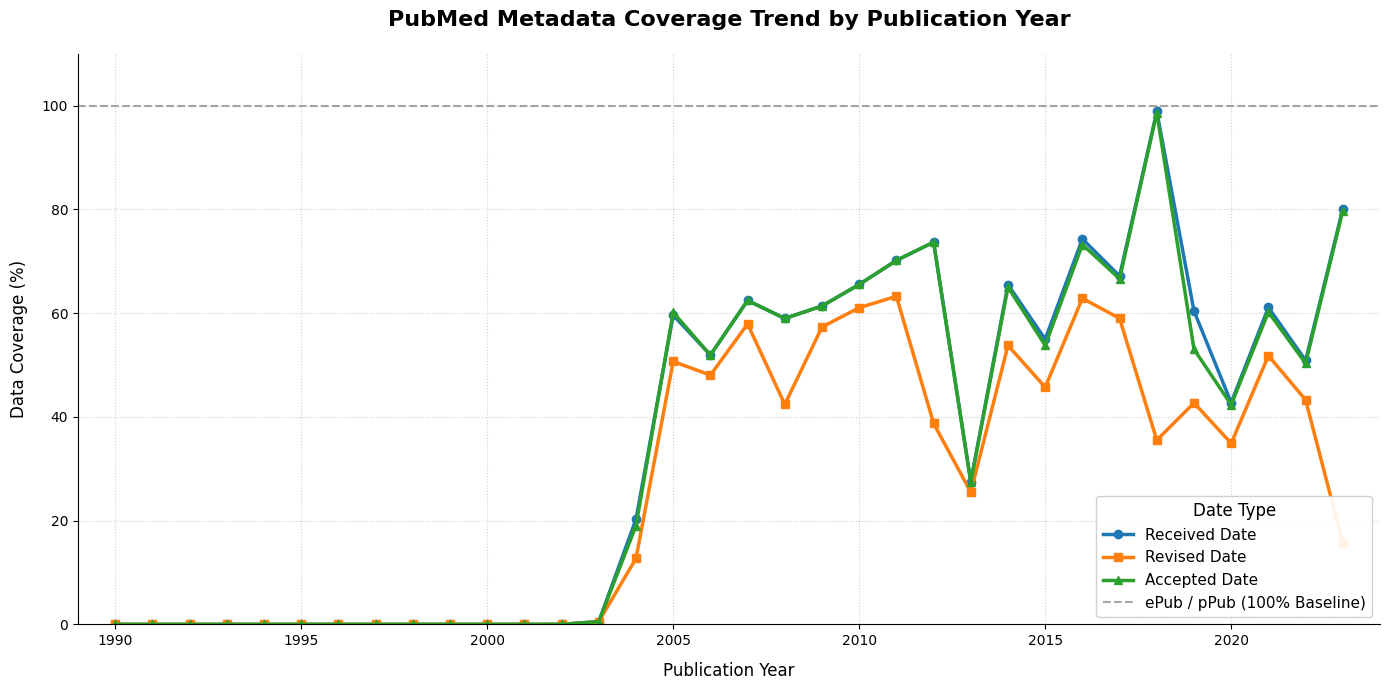

In [3]:
from src.database.connection_manager import db_manager
from src.etl.enrichment.validation import EnrichmentValidator

validator = EnrichmentValidator(db_manager)

validator.display_coverage_report()
validator.display_article_coverage_report(article_column="article_key")

validator.plot_coverage_trend()


### **Data Enrichment: Date Dimension Synchronization**

This final step bridges the gap between enriched fact data and the `dim_date`. It ensures that every new milestone (Received, Accepted, etc.) has a corresponding entry in the `dim_date` table.

* **Gap Detection:** Scans all 5 lifecycle columns for date keys that haven't been registered in the DWH yet.
* **On-the-fly Generation:** Automatically calculates metadata attributes (Month, Day Name, etc.) for these new temporal anchors.
* **Relational Integrity:** Guarantees that future SQL JOINs won't drop records due to missing date dimensions.

In [3]:
from src.etl.loading.warehouse_loader import WarehouseLoader

print("Finalizing ETL: Updating Date Dimension...")

warehouse_loader = WarehouseLoader()
warehouse_loader.update_date_dimension_from_facts()

Finalizing ETL: Updating Date Dimension...
Scanning fact table for missing date keys...


C:\MariaSamosudova\Projects\UNIVER\repos\ELIQSIR\ipai_project\src\etl\loading\warehouse_loader.py:141: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  missing_keys_df = pd.read_sql(union_query, conn)


All date keys are already present in dim_date. No update needed.


### **Data Enrichment: Dynamic Role Playing Date Dimension Integrity & Coverage Test**

In [4]:
from src.database.connection_manager import db_manager
from src.etl.enrichment.validation import EnrichmentValidator

validator = EnrichmentValidator(db_manager)
validator.run_architecture_report()

2026-04-16 16:13:59  INFO      src.etl.enrichment.validation  Executing comprehensive architecture report...

DATA QUALITY & ARCHITECTURE REPORT

1. Unique Dates by Type in Fact Table
  date_type  unique_dates
   Received          6487
    Revised          6170
   Accepted          6097
       ePub          6276
       pPub          2713
Publication          2042

2. Referential Integrity Check
 distinct_dates_in_facts  total_dates_in_dim  facts_missing_in_dim  dim_missing_in_facts
                    8690                8690                     0                     0

3. Macro Storage Compression
 total_fk_references_in_facts  total_physical_rows_in_dim
                     10920992                        8690

FINAL CONCLUSIONS
INTEGRITY: Dates in Facts exactly match the Dimension table.
COVERAGE: 100% Coverage. No orphan dates in Facts.
EFFICIENCY: Zero Excess. No unused dates in Dimension.

ARCHITECTURE: 8690 physical rows support 10,920,992 references.
